In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from compass import loadcompass, PreTrainer, FineTuner
from compass.tokenizer import CANCER_CODE
from compass.utils import plot_performance, score2

%matplotlib inline

In [2]:
# =========================================================
# 0. Environment setup
# =========================================================
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {device}")

# =========================================================
# 1. Define directories
# =========================================================
base_dir = "./results"
pt_path = f"{base_dir}/PT/pretrainer.pt"
save_dir = f"{base_dir}/FT"

os.makedirs(save_dir, exist_ok=True)

itrp_path = "./data/ITRP/15672/"
print(f"[INFO] Data path: {itrp_path}")


[INFO] Using device: cuda
[INFO] Data path: /mnt/shenwanxiang/Research/data/ITRP/15672/


In [3]:
# =========================================================
# 2. Load data
# =========================================================
_GLOBALS = {}

def load_itrp(path):
    """Load preprocessed ITRP pickle files (TPM and metadata)."""
    if "itrp_label" not in _GLOBALS:
        _GLOBALS["itrp_label"] = pd.read_pickle(os.path.join(path, "ITRP.PATIENT.TABLE"))
        _GLOBALS["itrp_tpm"] = pd.read_pickle(os.path.join(path, "ITRP.TPM.TABLE"))
    return _GLOBALS["itrp_label"], _GLOBALS["itrp_tpm"]

df_label, df_tpm = load_itrp(itrp_path)
print(f"[INFO] Loaded {df_label.shape[0]} patients × {df_tpm.shape[1]} genes")

[INFO] Loaded 1133 patients × 15672 genes


In [4]:
# =========================================================
# 3. Load pre-trained COMPASS model
# =========================================================
pretrainer = loadcompass(pt_path)
print(f"[INFO] Loaded pretrainer from {pt_path}")

# Ensure feature alignment
missing_genes = set(pretrainer.feature_name) - set(df_tpm.columns)
if missing_genes:
    print(f"[WARN] Missing {len(missing_genes)} genes from TPM table – they will be ignored.")
df_tpm = df_tpm[pretrainer.feature_name]

# Merge features with cancer code
dfcx = df_label.cancer_type.map(CANCER_CODE).to_frame("cancer_code").join(df_tpm)
df_task = pd.get_dummies(df_label.response_label, dummy_na=False)

[INFO] Loaded pretrainer from ./results/PT/pretrainer.pt


In [5]:
# =========================================================
# 4. Define cohort splits
# =========================================================
def leave_one_out(cohorts):
    return [(cohorts[i], cohorts[:i] + cohorts[i+1:]) for i in range(len(cohorts))]

cohorts = df_label.groupby("cohort").size().sort_values().index.tolist()
eva_cohorts = ["Gide", "Kim", "IMVigor210"]
train_test_pairs = [(test, train) for test, train in leave_one_out(cohorts) if test in eva_cohorts]

print(f"[INFO] Evaluation cohorts: {', '.join(eva_cohorts)}")

[INFO] Evaluation cohorts: Gide, Kim, IMVigor210


In [6]:
# =========================================================
# 5. Define fine-tuning parameters
# =========================================================
params = dict(
    mode="PFT",
    seed=42,
    lr=3e-3,
    weight_decay=1e-8,
    batch_size=32,
    max_epochs=20,
    device=device,
    task_loss_weight=1.0,
    task_loss_type="ce_loss",
    task_type="c",
    task_dense_layer=[24],
    task_batch_norms=True,
    entropy_weight=0.0,
    with_wandb=False,
    save_best_model=False,
    verbose=False,
)

work_dir = f"{save_dir}/ft_{params['mode']}_{params['seed']}"
os.makedirs(work_dir, exist_ok=True)

100%|#################################################################################| 19/19 [00:00<00:00, 30.71it/s]


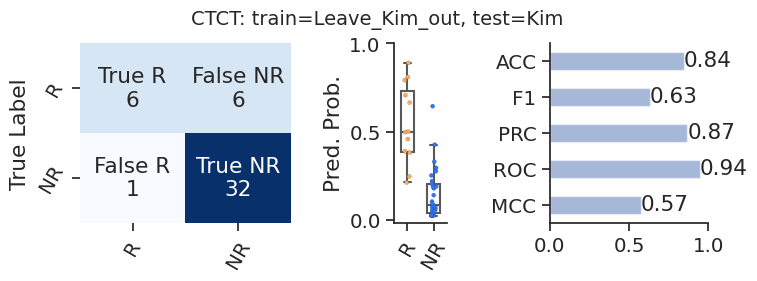

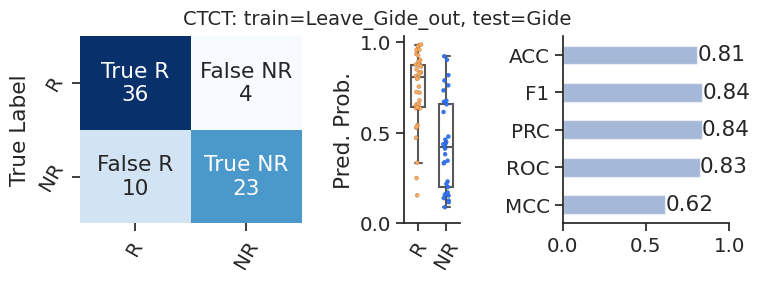

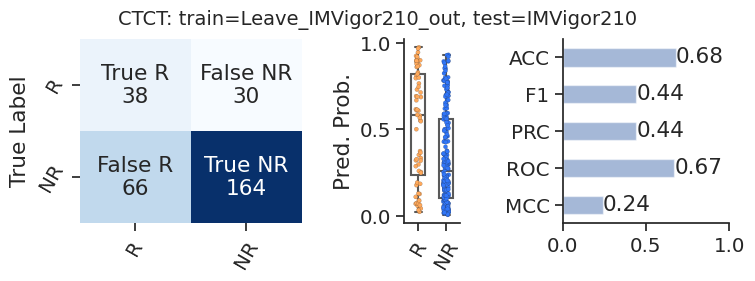

In [7]:
# =========================================================
# 6. Fine-tuning and evaluation loop
# =========================================================
results = []

for test_cohort, train_cohorts in train_test_pairs:
    train_name = f"Leave_{test_cohort}_out"

    # Split training and testing
    train_idx = df_label[df_label["cohort"].isin(train_cohorts)].index
    test_idx = df_label[df_label["cohort"] == test_cohort].index

    train_X, train_y = dfcx.loc[train_idx], df_task.loc[train_idx]
    test_X, test_y = dfcx.loc[test_idx], df_task.loc[test_idx]

    # Fine-tune
    model_ft = FineTuner(pretrainer.copy(), **params, work_dir=work_dir, task_name=train_name)
    model_ft = model_ft.tune(dfcx_train=train_X, dfy_train=train_y, min_mcc=0.8)

    # Predict
    _, pred = model_ft.predict(test_X, batch_size=16)
    pred["train_cohort"] = train_name
    pred["test_cohort"] = test_cohort
    pred["best_epoch"] = model_ft.best_epoch
    pred["n_trainable_params"] = model_ft.count_parameters()

    # Join with labels
    dfp = test_y.join(pred)
    y_true, y_prob, y_pred = dfp["R"], dfp[1], dfp[[0, 1]].idxmax(axis=1)

    # Plot performance
    fig = plot_performance(y_true, y_prob, y_pred)
    fig.suptitle(f"CTCT: train={train_name}, test={test_cohort}", fontsize=14)
    fig.savefig(os.path.join(work_dir, f"CTCT_train_{train_name}_test_{test_cohort}.jpg"))
    results.append(dfp)

In [9]:
# =========================================================
# 7. Aggregate metrics
# =========================================================
dfs = pd.concat(results)
metrics = dfs.groupby(["train_cohort", "test_cohort"]).apply(
    lambda x: score2(x["R"], x[1], x[[0, 1]].idxmax(axis=1))
).apply(pd.Series)
metrics.columns = ["ROC", "PRC", "F1", "ACC", "MCC"]
metrics = metrics.reset_index()

# Save results
dfs.to_csv(os.path.join(work_dir, "source_performance.tsv"), sep="\t", index=False)
metrics.to_csv(os.path.join(work_dir, "metric_performance.tsv"), sep="\t", index=False)

print(f"[DONE] Results saved to {work_dir}")

[DONE] Results saved to ./results/FT/ft_PFT_42
